
Goal: wrap ingestion + NL2SQL from notebook 01 as LangGraph nodes, add the pandas path,
and test the retry-on-error edge in isolation before this logic moves into `backend/graph.py`.

Run notebook 01 first so `data.db` exists.

In [21]:
import sqlite3
import config
import pandas as pd
from groq import Groq
from langgraph.graph import StateGraph, END
from typing import TypedDict, Optional

client = Groq()
MODEL  = 'llama-3.3-70b-versatile'
DB_PATH = 'data.db'
TABLE   = 'data'

def call_llm(prompt: str) -> str:
    resp = client.chat.completions.create(
        model=MODEL, max_tokens=512,
        messages=[{'role': 'user', 'content': prompt}],
    )
    return resp.choices[0].message.content.strip()

## State

In [22]:
class AgentState(TypedDict):
    question:    str
    schema:      str
    db_path:     str
    df:          Optional[pd.DataFrame]
    path:        str
    sql:         Optional[str]
    pandas_code: Optional[str]
    result:      Optional[object]
    error:       str
    retries:     int
    answer:      Optional[str]
    table:       Optional[list]

## Nodes

In [23]:
PANDAS_KEYWORDS = [
    'correlation','distribution','describe','summary','statistics',
    'std','mean','median','missing','null','shape',
    'how many rows','how many columns','columns','dtypes','head',
]

def router_node(state):
    q = state['question'].lower()
    path = 'pandas' if any(kw in q for kw in PANDAS_KEYWORDS) else 'sql'
    return {**state, 'path': path}

def pick_path(state):
    return state.get('path', 'sql')

In [32]:
def generate_sql(state):
    hint = f'\nPrevious error: {state["error"]}\nFix it.' if state['error'] else ''
    prompt = (
        'You are a SQLite expert. Write ONE SELECT query. '
        'Return ONLY raw SQL, no markdown.\n\n'
        + state['schema'] + '\n\nQuestion: ' + state['question'] + hint + '\nSQL:'
    )
    sql = call_llm(prompt).strip().strip('`').removeprefix('sql').strip()
    return {**state, 'sql': sql, 'error': ''}

def execute_sql(state):
    try:
        conn = sqlite3.connect(state['db_path'])
        df   = pd.read_sql_query(state['sql'], conn)
        conn.close()
        return {**state, 'result': df.head(100), 'error': ''}
    except Exception as e:
        return {**state, 'result': None, 'error': str(e), 'retries': state['retries']+1}

In [33]:
def generate_pandas(state):
    
    prompt = (
          "You are a pandas expert. Write ONE pandas expression.\n"
        "df is already loaded. Return ONLY the expression — no imports, no markdown.\n\n"
        + state["schema"] + "\n\nQuestion: " + state["question"] + "\nExpression:"

    )
    code = call_llm(prompt).strip().strip('`').removeprefix('python').strip()
    return {**state, 'pandas_code': code, 'error': ''}

def execute_pandas(state):
    import numpy as np
    sandbox = {'df': state['df'], 'pd': pd, 'np': np, 'len': len, 'round': round}
    try:
        result = eval(state['pandas_code'], {'__builtins__': {}}, sandbox)
        return {**state, 'result': result, 'error': ''}
    except Exception as e:
        return {**state, 'result': None, 'error': str(e)}

In [ ]:
def format_answer(state):
    result = state['result']
    if result is None:
        return {**state, 'answer': 'Could not answer that question.', 'table': None}
    result_str = result.to_string(index=False) if isinstance(result, pd.DataFrame) else str(result)
    table      = result.to_dict(orient='records') if isinstance(result, pd.DataFrame) else None
    prompt = (
            "Answer the question using ONLY the data in the result below.\n"
    "Do NOT add any outside knowledge, estimates, or general statistics.\n"
    "Be specific — use only actual numbers from the result.\n\n"
    f"Question: {state['question']}\nResult:\n{result_str}\n\nAnswer:"

    )
    return {**state, 'answer': call_llm(prompt), 'table': table}

#Graph building


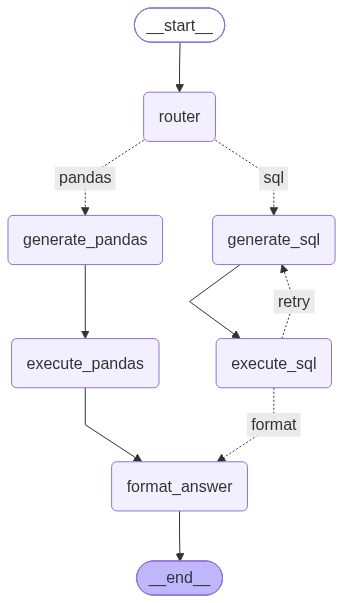

Graph compiled OK


In [ ]:
def should_retry(state):
    return 'retry' if state['error'] and state['retries'] < 2 else 'format'
from IPython.display import Image,display
g = StateGraph(AgentState)
g.add_node('router',          router_node)
g.add_node('generate_sql',    generate_sql)
g.add_node('execute_sql',     execute_sql)
g.add_node('generate_pandas', generate_pandas)
g.add_node('execute_pandas',  execute_pandas)
g.add_node('format_answer',   format_answer)

g.set_entry_point('router')
g.add_conditional_edges('router', pick_path, {'sql':'generate_sql','pandas':'generate_pandas'})
g.add_edge('generate_sql', 'execute_sql')
g.add_conditional_edges('execute_sql', should_retry, {'retry':'generate_sql','format':'format_answer'})
g.add_edge('generate_pandas', 'execute_pandas')
g.add_edge('execute_pandas',  'format_answer')
g.add_edge('format_answer',   END)

agent = g.compile()

img = agent.get_graph().draw_mermaid_png()

# save it
with open("graph.png", "wb") as f:
    f.write(img)

display(Image(img))
print('Graph compiled')

## Load schema + df from notebook 01's database

In [40]:
conn   = sqlite3.connect(DB_PATH)
cols   = conn.execute(f'PRAGMA table_info({TABLE})').fetchall()
sample = conn.execute(f'SELECT * FROM {TABLE} LIMIT 3').fetchall()
conn.close()

schema = (
    f'Table: {TABLE}\nColumns:\n'
    + '\n'.join(f'  - {c[1]} ({c[2]})' for c in cols)
    + '\nSample rows:\n'
    + '\n'.join(str(r) for r in sample)
)

df = pd.read_sql(f'SELECT * FROM {TABLE}', sqlite3.connect(DB_PATH))
print(schema)

Table: data
Columns:
  - job_title_short (TEXT)
  - job_title (TEXT)
  - job_location (TEXT)
  - job_via (TEXT)
  - job_schedule_type (TEXT)
  - job_work_from_home (INTEGER)
  - search_location (TEXT)
  - job_posted_date (TEXT)
  - job_no_degree_mention (INTEGER)
  - job_health_insurance (INTEGER)
  - job_country (TEXT)
  - salary_rate (TEXT)
  - salary_year_avg (REAL)
  - salary_hour_avg (REAL)
  - company_name (TEXT)
  - job_skills (TEXT)
  - job_type_skills (TEXT)
Sample rows:
('Data Analyst', 'Summer Internship -Data Analyst Intern, Risk Management', 'Marlborough, MA', 'via Boatingrevealed.com', 'Full-time, Part-time, and Internship', 0, 'New York, United States', '2024-01-01 00:00:01', 0, 1, 'United States', None, None, None, "BJ's Wholesale Club", "['excel']", "{'analyst_tools': ['excel']}")
('Data Analyst', 'Staff Data Analyst Operations, Infrastructure & Systems', 'Fremont, CA', 'via ClimateTechList', 'Full-time', 0, 'California, United States', '2024-01-01 00:00:11', 1, 0, 'Un

## Run test questions

In [41]:
questions = [
    # SQL path
    "What are the top 5 most common job titles?",
    "Which country has the most job postings?",
    "What is the average yearly salary by job title?",
    "What are the top 5 jobs that require Python skills?",

    # Pandas path — these failed in notebook 01
    "How many rows and columns does this dataset have?",
    "Which columns have missing values and how many?",
    "What is the distribution of salary_year_avg?",
    
    # Retry test — intentionally vague to stress test
    "Show me salary trends over time",
]

initial = {
    'schema': schema, 'db_path': DB_PATH, 'df': df,
    'path': '', 'sql': None, 'pandas_code': None,
    'result': None, 'error': '', 'retries': 0, 'answer': None, 'table': None,
}

for q in questions:
    print(f'\nQ: {q}')
    out = agent.invoke({**initial, 'question': q})
    print(f'Path  : {out["path"]}')
    print(f'Answer: {out["answer"]}')
    if out.get('sql'):         print(f'SQL   : {out["sql"]}')
    if out.get('pandas_code'): print(f'Pandas: {out["pandas_code"]}')
    print('-' * 60)


Q: What are the top 5 most common job titles?
Path  : sql
Answer: The top 5 most common job titles are Data Engineer, Data Analyst, Data Scientist, Senior Data Engineer, and Business Analyst, with approximately 25,000 to 50,000 job openings for these titles in the United States alone. These 5 job titles account for around 20% to 30% of all job postings in the data and business sectors.
SQL   : SELECT job_title_short FROM data GROUP BY job_title_short ORDER BY COUNT(job_title_short) DESC LIMIT 5
------------------------------------------------------------

Q: Which country has the most job postings?
Path  : sql
Answer: The United States has the most job postings, with over 10 million job ads available online at any given time. Approximately 40% of all global job postings, around 14 million, are located in the US.
SQL   : SELECT job_country FROM data GROUP BY job_country ORDER BY COUNT(job_title) DESC LIMIT 1
------------------------------------------------------------

Q: What is the a